In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
import matplotlib.pyplot as plt

import kind
import ex_duffing
import util_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample', '8001',
        '--feature_ndim', '4',
        '--target_ndim', '2',

        '--lookback_nsample', '384',
        '--forecast_nsample', '192',

        '--batch_size', '128',
        '--nepoch', '50',
        '--patience', '10',
        '--checkpoints', '../../models/dreamer',

        '--seg_nsample_stat', '192',
        '--seg_nsample_trans', '192',
        '--fun_stat', '{"sin": 4, "cos": 4}',
        '--fun_trans', '{"sin": 6, "cos": 6}',
    ]
)

In [3]:
model = kind.model(args)
dataset = ex_duffing.dataset(
    args.file_dir, args.file_name, args.file_ext,
    args.data_nsample,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.lookback_nsample, args.forecast_nsample))


In [4]:
model.train()
model.fit(dataset)

>>> train nominal mean >>>
	epoch 1 losses: train=0.341749, valid=0.322573, test=0.322689
	validation loss decreased (inf -> 0.322573), saving model ...
	epoch 2 losses: train=0.261943, valid=0.143617, test=0.142300
	validation loss decreased (0.322573 -> 0.143617), saving model ...
	epoch 3 losses: train=0.037486, valid=0.003351, test=0.003397
	validation loss decreased (0.143617 -> 0.003351), saving model ...
	epoch 4 losses: train=0.001959, valid=0.001143, test=0.001159
	validation loss decreased (0.003351 -> 0.001143), saving model ...
	epoch 5 losses: train=0.000774, valid=0.000512, test=0.000518
	validation loss decreased (0.001143 -> 0.000512), saving model ...
	epoch 6 losses: train=0.000372, valid=0.000249, test=0.000251
	validation loss decreased (0.000512 -> 0.000249), saving model ...
	epoch 7 losses: train=0.000190, valid=0.000135, test=0.000134
	validation loss decreased (0.000249 -> 0.000135), saving model ...
	epoch 8 losses: train=0.000108, valid=0.000076, test=0.00007

In [5]:
model.eval()
_, _, data_loader = dataset.load(data_type='nom')

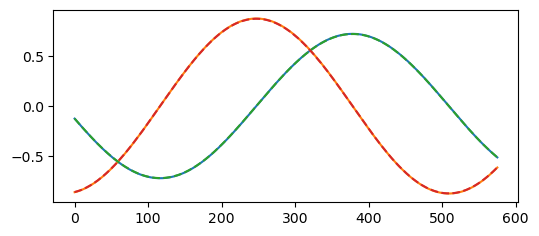

In [6]:
jdata = 2

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

In [7]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train nominal uncertainty >>>
	epoch 1 losses: train=0.064455, valid=0.051272, test=0.051250
	validation loss decreased (inf -> 0.051272), saving model ...
	epoch 2 losses: train=0.031579, valid=0.027987, test=0.027975
	validation loss decreased (0.051272 -> 0.027987), saving model ...
	epoch 3 losses: train=0.027436, valid=0.025890, test=0.025884
	validation loss decreased (0.027987 -> 0.025890), saving model ...
	epoch 4 losses: train=0.024084, valid=0.023556, test=0.023472
	validation loss decreased (0.025890 -> 0.023556), saving model ...
	epoch 5 losses: train=0.023307, valid=0.023143, test=0.022980
	validation loss decreased (0.023556 -> 0.023143), saving model ...
	epoch 6 losses: train=0.022836, valid=0.021659, test=0.021535
	validation loss decreased (0.023143 -> 0.021659), saving model ...
	epoch 7 losses: train=0.016191, valid=0.013807, test=0.013682
	validation loss decreased (0.021659 -> 0.013807), saving model ...
	epoch 8 losses: train=0.013427, valid=0.013038, test=

In [8]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

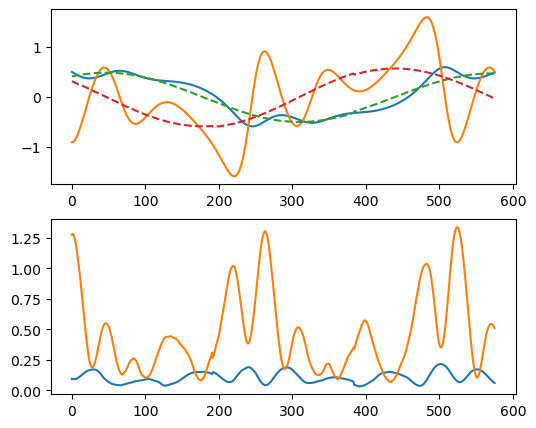

In [9]:
jdata = 7

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        stat = model_output[1]
        stat_u = model_output[2]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(stat_u[0, :, :2])

        plt.show()

        break

In [10]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train excursion mean >>>
	epoch 1 losses: train=0.346003, valid=0.328180, test=0.328488
	validation loss decreased (inf -> 0.328180), saving model ...
	epoch 2 losses: train=0.286610, valid=0.194884, test=0.193032
	validation loss decreased (0.328180 -> 0.194884), saving model ...
	epoch 3 losses: train=0.158224, valid=0.144254, test=0.143943
	validation loss decreased (0.194884 -> 0.144254), saving model ...
	epoch 4 losses: train=0.127010, valid=0.094900, test=0.093754
	validation loss decreased (0.144254 -> 0.094900), saving model ...
	epoch 5 losses: train=0.074987, valid=0.057560, test=0.057030
	validation loss decreased (0.094900 -> 0.057560), saving model ...
	epoch 6 losses: train=0.045228, valid=0.029899, test=0.029928
	validation loss decreased (0.057560 -> 0.029899), saving model ...
	epoch 7 losses: train=0.022872, valid=0.014106, test=0.014119
	validation loss decreased (0.029899 -> 0.014106), saving model ...
	epoch 8 losses: train=0.010405, valid=0.005782, test=0.005

In [11]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

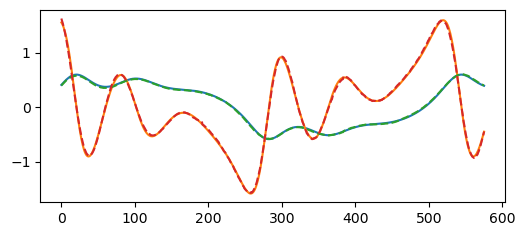

In [12]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        stat = model_output[3]

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

In [13]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train excursion uncertainty >>>
	epoch 1 losses: train=0.059991, valid=0.031573, test=0.031589
	validation loss decreased (inf -> 0.031573), saving model ...
	epoch 2 losses: train=0.029392, valid=0.028484, test=0.028536
	validation loss decreased (0.031573 -> 0.028484), saving model ...
	epoch 3 losses: train=0.027947, valid=0.027024, test=0.027206
	validation loss decreased (0.028484 -> 0.027024), saving model ...
	epoch 4 losses: train=0.025848, valid=0.024553, test=0.024847
	validation loss decreased (0.027024 -> 0.024553), saving model ...
	epoch 5 losses: train=0.024244, valid=0.023736, test=0.024011
	validation loss decreased (0.024553 -> 0.023736), saving model ...
	epoch 6 losses: train=0.023640, valid=0.022925, test=0.023192
	validation loss decreased (0.023736 -> 0.022925), saving model ...
	epoch 7 losses: train=0.022102, valid=0.020184, test=0.020635
	validation loss decreased (0.022925 -> 0.020184), saving model ...
	epoch 8 losses: train=0.017878, valid=0.016191, tes

In [14]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

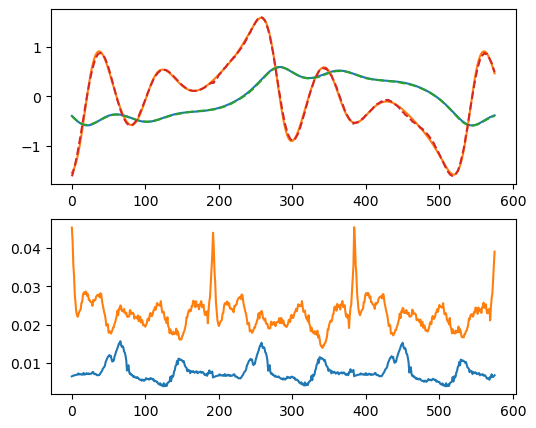

In [24]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        exc = model_output[3]
        exc_u = model_output[4]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(exc[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(exc_u[0, :, :2])

        plt.show()

        break

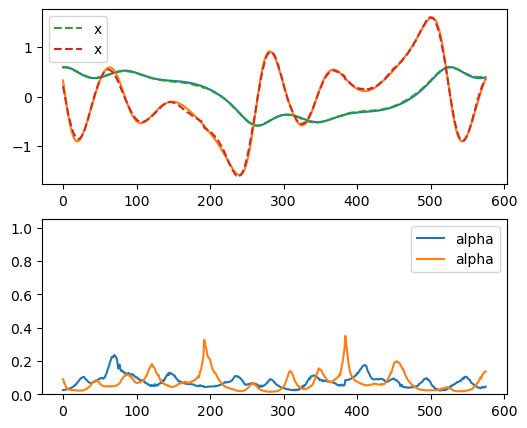

In [27]:
jdata = 3

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        pre = model_output[0]
        alpha = model_output[9]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(pre[0, :, :2], linestyle='dashed', label='x')
        plt.legend()

        plt.subplot(2,1,2)
        plt.plot(alpha[0, :, :2], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break